# LISA: sensitivity, response, and the global fit

**FQCP 2026 · Bayesian parameter estimation for gravitational-wave sources**

> Google Colab worksheet for early-stage graduate students. Run from top to
> bottom; **Extension** sections may be skipped live.

## Goal and analysis map

This notebook follows the LISA Analysis Tools Workshop progression:

$$
\text{sensitivity}\rightarrow\text{TDI data}\rightarrow(a\mid b)
\rightarrow\mathrm{SNR}\rightarrow\mathcal L\rightarrow
\text{single source}\rightarrow\text{unknown overlapping catalogue}.
$$

We use `lisatools` for LISA sensitivity curves and its `AnalysisContainer`, and
JaxGB for an actual moving-constellation Galactic-binary response. You will
first calculate a frequency likelihood manually, then verify the same objects
through the LISA Analysis Tools interface. The final exercise is a miniature
version of the LATW global-fit challenge.

In [1]:
import os, sys, subprocess, importlib.util

IN_COLAB = "COLAB_RELEASE_TAG" in os.environ
needed = ("lisatools", "gpubackendtools", "jaxgb", "eryn")
if any(importlib.util.find_spec(package) is None for package in needed):
    if IN_COLAB:
        subprocess.check_call(
            [
                sys.executable,
                "-m",
                "pip",
                "install",
                "-q",
                "lisaanalysistools==1.2.5",
                "gpubackendtools==0.1.1",
                "jaxgb==0.2.1",
                "astropy==7.2.0",
                "eryn==1.2.6",
            ]
        )
    else:
        raise ImportError("Install the pinned LISA requirements, or run in Colab.")

In [2]:
import itertools
import warnings
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from matplotlib.animation import FuncAnimation
from jax import config

config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", message="IProgress not found.*")
from lisatools.sensitivity import (
    A1TDISens,
    E1TDISens,
    SensitivityMatrix,
    get_sensitivity,
)
from lisatools.utils.constants import YRSID_SI
from lisaorbits import EqualArmlengthOrbits
from jaxgb.jaxgb import JaxGB
from jaxgb.params import GBObject

rng = np.random.default_rng(20260817)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["animation.html"] = "jshtml"

## 1. LISA's band and source zoo

Ground-based detectors observe roughly tens of Hz to kHz. LISA targets approximately $10^{-4}$–$10^{-1}$ Hz, containing Galactic compact binaries, massive-black-hole binaries, EMRIs, stellar-origin binaries, stochastic backgrounds, and instrument noise. Long observations make many signals overlap.

Unlike a static right-angle detector, LISA is a heliocentric triangle that cartwheels as it orbits. Six delayed one-way laser links are combined into time-delay interferometry (TDI) variables. Orbital modulation helps localisation, while finite arms create a frequency-dependent response.

### Why LISA parameter estimation is unusually coupled

| Feature | Typical transient LVK CBC analysis | LISA analysis |
| --- | --- | --- |
| signal duration in band | seconds to minutes for many CBCs | months to years for many sources |
| response during one signal | detector geometry often changes little | constellation motion modulates the signal |
| data channels | separated ground detectors | correlated laser links combined into TDI |
| source overlap | often analyse a short segment around one event | many persistent sources share the same bins |
| noise/foreground | PSD estimated around an event, with caveats | instrument noise and astrophysical foreground may evolve together |
| catalogue size | event trigger supplies a candidate | number of resolvable sources can be unknown |

The hard part is not that Bayes' theorem changes. The signal, response, noise,
and catalogue blocks become more strongly coupled, so fitting one source while
treating everything else as fixed can bias the residual seen by the next
source.

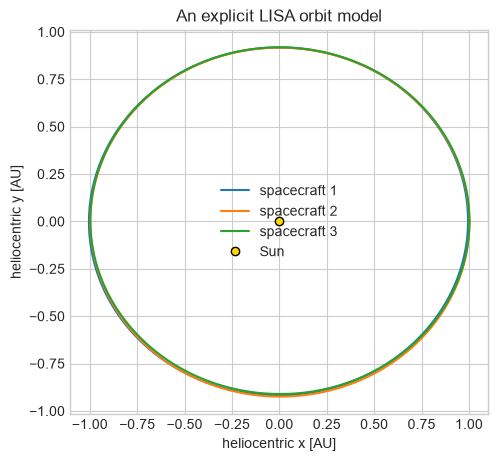

In [3]:
year = YRSID_SI
AU = 149597870700.0
orbits = EqualArmlengthOrbits()
times = np.linspace(0, year, 240)
positions = np.asarray(orbits.compute_position(times, [1, 2, 3]))
fig, ax = plt.subplots(figsize=(5.4, 5.4))
for i, label in enumerate(["spacecraft 1", "spacecraft 2", "spacecraft 3"]):
    ax.plot(positions[:, i, 0] / AU, positions[:, i, 1] / AU, label=label)
ax.plot(0, 0, "o", color="gold", mec="k", label="Sun")
ax.set(
    xlabel="heliocentric x [AU]",
    ylabel="heliocentric y [AU]",
    title="An explicit LISA orbit model",
    aspect="equal",
)
ax.legend()
plt.show()

### Fast animation: the moving constellation

The orbital motion is not decorative: it amplitude-, phase-, and frequency-modulates long-lived signals and encodes sky position. This animation uses precomputed orbit coordinates, so it remains fast in Colab.

In [4]:
orbit_frames = np.arange(0, len(times), 10)
fig, ax = plt.subplots(figsize=(5.2, 5.2))
(triangle,) = ax.plot([], [], "o-", lw=1.5)
trail_lines = [ax.plot([], [], alpha=0.35)[0] for _ in range(3)]
ax.plot(0, 0, "o", color="gold", mec="k")
ax.set(
    xlim=(-1.12, 1.12),
    ylim=(-1.12, 1.12),
    aspect="equal",
    xlabel="x [AU]",
    ylabel="y [AU]",
)


def animate_constellation(frame):
    i = orbit_frames[frame]
    current = positions[i, :, :2] / AU
    closed = np.vstack([current, current[0]])
    triangle.set_data(closed[:, 0], closed[:, 1])
    for spacecraft, line in enumerate(trail_lines):
        line.set_data(
            positions[: i + 1, spacecraft, 0] / AU,
            positions[: i + 1, spacecraft, 1] / AU,
        )
    ax.set_title(f"LISA constellation: day {times[i]/86400:.0f}")
    return (triangle, *trail_lines)


orbit_animation = FuncAnimation(
    fig, animate_constellation, frames=len(orbit_frames), interval=90
)
plt.close(fig)
display(HTML(orbit_animation.to_jshtml()))

## 2. Sensitivity and Galactic confusion

As in LATW Tutorial 1, start with the noise model. The unresolved Galactic foreground changes with observing time because longer data resolve and subtract more binaries.

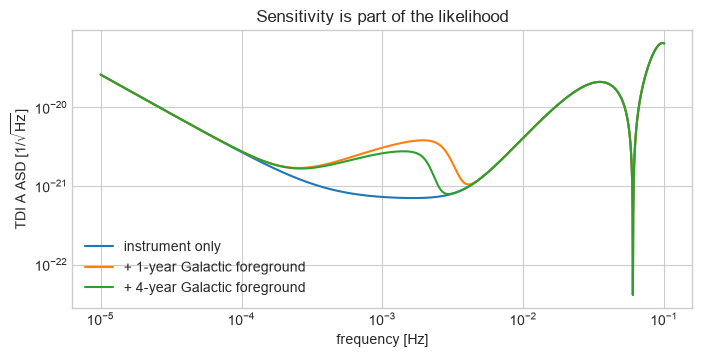

In [5]:
f_curve = np.logspace(-5, -1, 1800)
instrument = SensitivityMatrix(f_curve, [A1TDISens, E1TDISens])
one_year = SensitivityMatrix(
    f_curve, [A1TDISens, E1TDISens], stochastic_params=(1 * year,)
)
four_year = SensitivityMatrix(
    f_curve, [A1TDISens, E1TDISens], stochastic_params=(4 * year,)
)
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.loglog(f_curve, np.sqrt(instrument.sens_mat[0]), label="instrument only")
ax.loglog(f_curve, np.sqrt(one_year.sens_mat[0]), label="+ 1-year Galactic foreground")
ax.loglog(f_curve, np.sqrt(four_year.sens_mat[0]), label="+ 4-year Galactic foreground")
ax.set(
    xlabel="frequency [Hz]",
    ylabel=r"TDI A ASD [1/$\sqrt{\mathrm{Hz}}$]",
    title="Sensitivity is part of the likelihood",
)
ax.legend()
plt.show()

## 3. Real LISA data will be more complicated

| Complication | What students should ask | Analysis consequence |
| --- | --- | --- |
| data gaps and irregular availability | why is data missing; is the gap informative? | Fourier bins become coupled; windowing/inpainting/gap-aware likelihoods |
| time-varying instrument noise | is one mission-long PSD meaningful? | segmented, time-frequency, or explicitly non-stationary noise models |
| changing Galactic foreground | which binaries become resolvable with time? | foreground and catalogue must be inferred together |
| moving/breathing constellation | are delays and orbits known accurately enough? | time-dependent link response and TDI generation |
| glitches, clock/laser artefacts, calibration | can an instrumental transient mimic a source? | extra nuisance models, vetoes, robust likelihoods |
| overlapping source classes | what belongs to the residual? | global rather than source-by-source inference |
| unknown catalogue size | how many binaries are present? | trans-dimensional/RJ methods and label-switching care |

The following lightweight laboratory is intentionally editable. Change the gap, drift, and noise-growth parameters and rerun it.

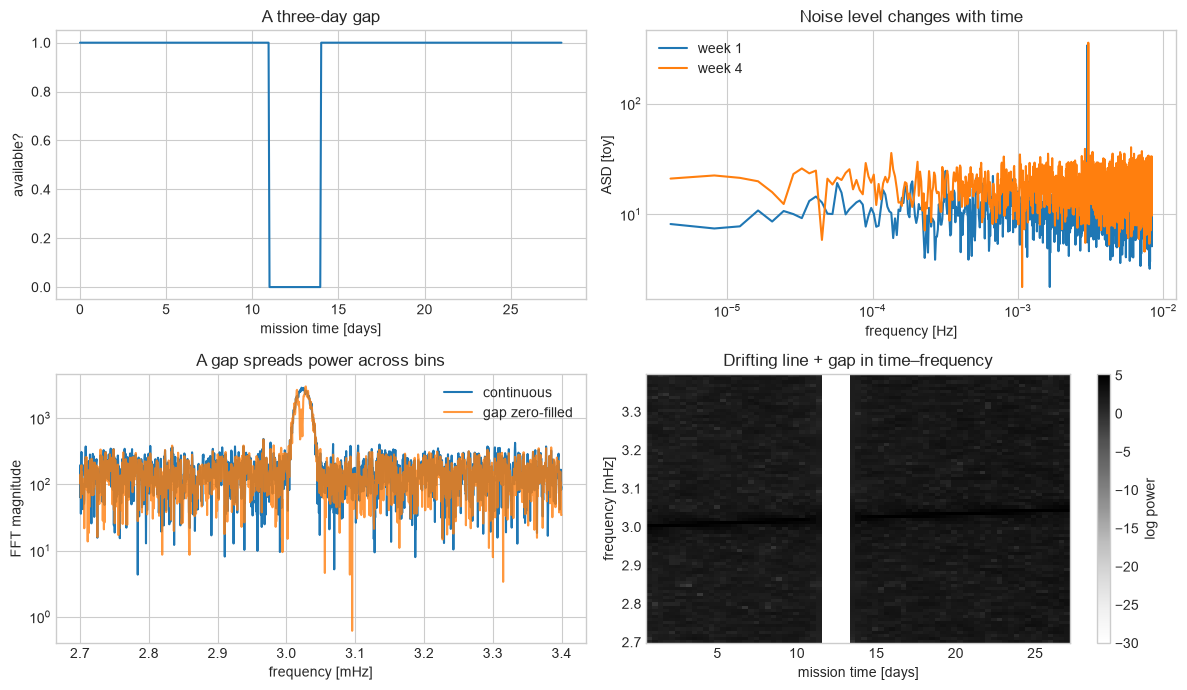

In [6]:
from scipy.signal import welch, spectrogram

# Student playground: all three controls are deliberately visible.
GAP_DAYS = (11, 14)
FREQUENCY_DRIFT = 2e-11
NOISE_GROWTH = 0.9
cadence = 60.0
mission_days = 28.0
toy_time = np.arange(0, mission_days * 86400, cadence)
sample_rate_toy = 1 / cadence
noise_scale = 1 + NOISE_GROWTH * toy_time / toy_time[-1]
phase = 2 * np.pi * (3e-3 * toy_time + 0.5 * FREQUENCY_DRIFT * toy_time**2)
continuous_data = noise_scale * rng.normal(size=toy_time.size) + 1.5 * np.sin(phase)
available = ~((toy_time >= GAP_DAYS[0] * 86400) & (toy_time < GAP_DAYS[1] * 86400))
gapped_data = continuous_data.copy()
gapped_data[~available] = 0  # zero fill only to expose leakage below

early = continuous_data[toy_time < 7 * 86400]
late = continuous_data[toy_time > 21 * 86400]
f_early, p_early = welch(early, fs=sample_rate_toy, nperseg=4096)
f_late, p_late = welch(late, fs=sample_rate_toy, nperseg=4096)
window = np.hanning(toy_time.size)
fft_frequency = np.fft.rfftfreq(toy_time.size, cadence)
fft_full = np.abs(np.fft.rfft(window * continuous_data))
fft_gap = np.abs(np.fft.rfft(window * gapped_data))
f_spec, t_spec, p_spec = spectrogram(
    gapped_data, fs=sample_rate_toy, nperseg=2048, noverlap=1536
)

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes[0, 0].plot(toy_time[::80] / 86400, available[::80].astype(int))
axes[0, 0].set(
    xlabel="mission time [days]", ylabel="available?", title="A three-day gap"
)
axes[0, 1].loglog(f_early[1:], np.sqrt(p_early[1:]), label="week 1")
axes[0, 1].loglog(f_late[1:], np.sqrt(p_late[1:]), label="week 4")
axes[0, 1].set(
    xlabel="frequency [Hz]", ylabel="ASD [toy]", title="Noise level changes with time"
)
axes[0, 1].legend()
near = (fft_frequency > 2.7e-3) & (fft_frequency < 3.4e-3)
axes[1, 0].semilogy(1e3 * fft_frequency[near], fft_full[near], label="continuous")
axes[1, 0].semilogy(
    1e3 * fft_frequency[near], fft_gap[near], label="gap zero-filled", alpha=0.8
)
axes[1, 0].set(
    xlabel="frequency [mHz]",
    ylabel="FFT magnitude",
    title="A gap spreads power across bins",
)
axes[1, 0].legend()
band = (f_spec > 2.7e-3) & (f_spec < 3.4e-3)
image = axes[1, 1].pcolormesh(
    t_spec / 86400, 1e3 * f_spec[band], np.log10(p_spec[band] + 1e-30), shading="auto"
)
axes[1, 1].set(
    xlabel="mission time [days]",
    ylabel="frequency [mHz]",
    title="Drifting line + gap in time–frequency",
)
fig.colorbar(image, ax=axes[1, 1], label="log power")
fig.tight_layout()
plt.show()

**Do not interpret zero-filling as the recommended gap treatment.** It is used here because its spectral leakage is immediately visible. A research analysis must define how gaps, edges, non-stationarity, and missing-data uncertainty enter the likelihood.

### Suggested investigations

- Set `GAP_DAYS=(0, 0)` and verify that the leakage pattern changes.
- Increase `FREQUENCY_DRIFT`; when does a stationary single-bin model fail?
- Fit the early PSD to late data. Which likelihood assumption is violated?
- Replace the hard gap with a taper and compare leakage against loss of usable data.
- Add a short glitch inside versus outside the gap.

## 4. Inner product, SNR, and likelihood

For independent A and E channels,
$$
(a\mid b)=4\Delta f\,\mathrm{Re}\sum_{X\in\{A,E\},k}\frac{a_{Xk}^*b_{Xk}}{S_X(f_k)},
\quad\rho_{\rm opt}=\sqrt{(h\mid h)},
\quad\log\mathcal L=-\tfrac12(d-h\mid d-h).
$$

These are the same objects as in LVK analysis. What changes is the instrument response, source durations, channels, band, and global model.

90-day optimal A+E SNR: 12.06


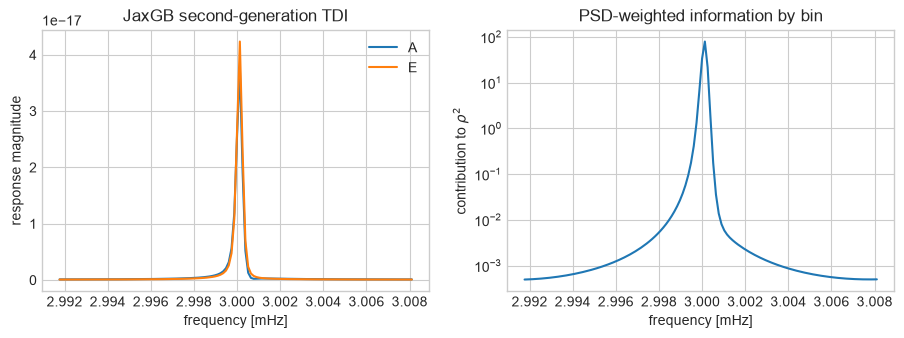

In [7]:
t_obs = 90 * 86400.0
simulator = JaxGB(orbits, t_obs=t_obs, t0=0, n=128)
source = GBObject(
    f0=np.array([3e-3]),
    fdot=np.array([1e-17]),
    A=np.array([2e-22]),
    ra=np.array([1.0]),
    dec=np.array([0.4]),
    psi=np.array([0.3]),
    iota=np.array([0.8]),
    phi0=np.array([0.2]),
    t_init=0.0,
)
parameters = source.to_jaxgb_array(t0=0)
A, E, T = simulator.get_tdi(parameters, tdi_generation=2, tdi_combination="AET")
frequency = np.asarray(
    simulator.get_frequency_grid(simulator.get_kmin(parameters[:, 0]))
)[0]
df = 1 / t_obs
template = np.stack([np.asarray(A)[0], np.asarray(E)[0]])
psd = np.stack(
    [
        get_sensitivity(frequency, sens_fn=A1TDISens, stochastic_params=(t_obs,)),
        get_sensitivity(frequency, sens_fn=E1TDISens, stochastic_params=(t_obs,)),
    ]
)


def inner(a, b):
    return 4 * df * np.real(np.sum(np.conj(a) * b / psd))


optimal_snr = np.sqrt(inner(template, template))
print(f"90-day optimal A+E SNR: {optimal_snr:.2f}")
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].plot(1e3 * frequency, np.abs(template[0]), label="A")
axes[0].plot(1e3 * frequency, np.abs(template[1]), label="E")
axes[0].set(
    xlabel="frequency [mHz]",
    ylabel="response magnitude",
    title="JaxGB second-generation TDI",
)
axes[0].legend()
axes[1].semilogy(1e3 * frequency, 4 * df * np.sum(np.abs(template) ** 2 / psd, axis=0))
axes[1].set(
    xlabel="frequency [mHz]",
    ylabel=r"contribution to $\rho^2$",
    title="PSD-weighted information by bin",
)
plt.show()

### Manual one-parameter likelihood

Perturb the source frequency, regenerate the moving-constellation response, and
compare optimal SNR with detected/matched SNR. A loud template can still match
the data poorly.

Watch the two scales in the plots below. The overlap between two templates
decays once they are separated by about one frequency bin, $1/T_{\rm obs}$.
The *likelihood* is narrower than that by roughly the signal-to-noise ratio,
which is why a 90-day observation pins $f_0$ to a small fraction of a bin.
Longer missions help twice over: more bins, and more SNR per source.

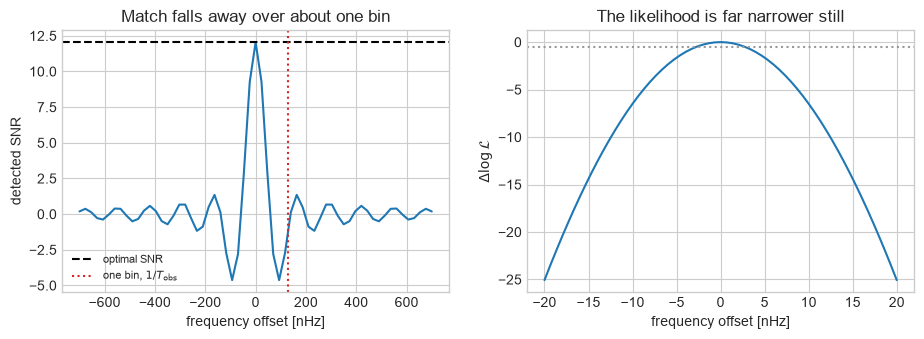

one frequency bin      : 1.286e-07 Hz
plotted likelihood span: 4.000e-08 Hz


In [8]:
def trial_template(f0_offset):
    """Regenerate the moving-constellation response at a shifted frequency."""
    trial = GBObject(
        f0=np.array([3e-3 + f0_offset]),
        fdot=np.array([1e-17]),
        A=np.array([2e-22]),
        ra=np.array([1.0]),
        dec=np.array([0.4]),
        psi=np.array([0.3]),
        iota=np.array([0.8]),
        phi0=np.array([0.2]),
        t_init=0.0,
    )
    kmin = int(simulator.get_kmin(parameters[:, 0])[0])
    a, e, _ = simulator.sum_tdi(
        trial.to_jaxgb_array(t0=0),
        kmin,
        kmin + simulator.n,
        tdi_generation=2,
        tdi_combination="AET",
    )
    return np.stack([np.asarray(a), np.asarray(e)])


# Two very different scales matter here. The overlap between templates decays
# over roughly a frequency bin, 1/T_obs, but the likelihood is narrower than
# that by about the signal-to-noise ratio.
wide_offsets = np.linspace(-7e-7, 7e-7, 61)
detected = []
for offset in wide_offsets:
    h = trial_template(offset)
    detected.append(inner(template, h) / np.sqrt(inner(h, h)))

offsets = np.linspace(-2e-8, 2e-8, 61)
logL, trial_templates = [], []
for offset in offsets:
    h = trial_template(offset)
    trial_templates.append(h)
    logL.append(-0.5 * inner(template - h, template - h))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].plot(1e9 * wide_offsets, detected)
axes[0].axhline(optimal_snr, color="k", ls="--", label="optimal SNR")
axes[0].axvline(1e9 / t_obs, color="C3", ls=":", label=r"one bin, $1/T_{\rm obs}$")
axes[0].set(
    xlabel="frequency offset [nHz]",
    ylabel="detected SNR",
    title="Match falls away over about one bin",
)
axes[0].legend(fontsize=8)
axes[1].plot(1e9 * offsets, np.array(logL) - np.max(logL))
axes[1].axhline(-0.5, color="0.6", ls=":")
axes[1].set(
    xlabel="frequency offset [nHz]",
    ylabel=r"$\Delta \log \mathcal{L}$",
    title="The likelihood is far narrower still",
)
plt.show()

print(f"one frequency bin      : {1 / t_obs:.3e} Hz")
print(f"plotted likelihood span: {offsets[-1] - offsets[0]:.3e} Hz")

### From a likelihood scan to a forecast: the Fisher matrix

The scan above varied one parameter and held the rest fixed. That is a
**conditional** slice, not a posterior width. To forecast what LISA measures,
the standard tool is the Fisher matrix,

$$
F_{ij}=\left(\frac{\partial h}{\partial\theta_i}\Big|
\frac{\partial h}{\partial\theta_j}\right),\qquad
\sigma_i^{\rm marginal}=\sqrt{(F^{-1})_{ii}},\qquad
\sigma_i^{\rm conditional}=1/\sqrt{F_{ii}}.
$$

We build it by finite-differencing the *full moving-constellation TDI
response*, so the derivatives include the orbital modulation. Two checks make
this concrete:

- amplitude is a pure scaling, so $\sigma_{\ln A}$ must equal $1/\rho$ exactly;
- the frequency scan from the previous cell must reproduce the **conditional**
  error, which is smaller than the marginal one by $\sqrt{1-\rho_{f_0\phi_0}^2}$.

That second point is the LISA-scale version of the lesson from the basics
notebook: marginalising over a correlated parameter is not the same as fixing
it, and quoting a conditional error as if it were a measurement uncertainty
understates it. Fisher forecasts are cheap and ubiquitous, but they assume high
SNR and near-linearity; at low SNR the real posterior is not an ellipse.

In [9]:
fisher_truth = dict(
    f0=3e-3, fdot=1e-17, A=2e-22, ra=1.0, dec=0.4, psi=0.3, iota=0.8, phi0=0.2
)


def fisher_response(**overrides):
    """TDI A and E on the fixed band, for the source with parameters replaced."""
    values = dict(fisher_truth)
    values.update(overrides)
    array = GBObject(
        **{key: np.array([value]) for key, value in values.items()}, t_init=0.0
    ).to_jaxgb_array(t0=0)
    a, e, _ = simulator.sum_tdi(
        array,
        int(simulator.get_kmin(parameters[:, 0])[0]),
        int(simulator.get_kmin(parameters[:, 0])[0]) + simulator.n,
        tdi_generation=2,
        tdi_combination="AET",
    )
    return np.stack([np.asarray(a), np.asarray(e)])


def derivative(key, step):
    """Central difference; amplitude is differentiated with respect to log A."""
    if key == "A":
        plus = fisher_response(A=fisher_truth["A"] * np.exp(step))
        minus = fisher_response(A=fisher_truth["A"] * np.exp(-step))
    else:
        plus = fisher_response(**{key: fisher_truth[key] + step})
        minus = fisher_response(**{key: fisher_truth[key] - step})
    return (plus - minus) / (2 * step)


fisher_labels = [r"$f_0$", r"$\ln A$", r"$\phi_0$"]
derivatives = [derivative("f0", 1e-9), derivative("A", 1e-3), derivative("phi0", 1e-3)]
fisher_matrix = np.array([[inner(a, b) for b in derivatives] for a in derivatives])
fisher_covariance = np.linalg.inv(fisher_matrix)

marginal_sd = np.sqrt(np.diag(fisher_covariance))
conditional_sd = 1 / np.sqrt(np.diag(fisher_matrix))
correlation = fisher_covariance / np.outer(marginal_sd, marginal_sd)

print(f"optimal SNR                 : {optimal_snr:.3f}")
print(f"sigma(ln A) from the Fisher : {marginal_sd[1]:.6f}")
print(f"1 / SNR                     : {1 / optimal_snr:.6f}")
print(f"f0-phi0 correlation         : {correlation[0, 2]:+.3f}")
print()
print(f"marginal    sigma(f0) : {marginal_sd[0]:.3e} Hz")
print(f"conditional sigma(f0) : {conditional_sd[0]:.3e} Hz")
print(f"ratio                 : {conditional_sd[0] / marginal_sd[0]:.3f}")
print(f"sqrt(1 - rho^2)       : {np.sqrt(1 - correlation[0, 2] ** 2):.3f}")

optimal SNR                 : 12.056
sigma(ln A) from the Fisher : 0.082948
1 / SNR                     : 0.082948
f0-phi0 correlation         : +0.904

marginal    sigma(f0) : 6.446e-09 Hz
conditional sigma(f0) : 2.759e-09 Hz
ratio                 : 0.428
sqrt(1 - rho^2)       : 0.428


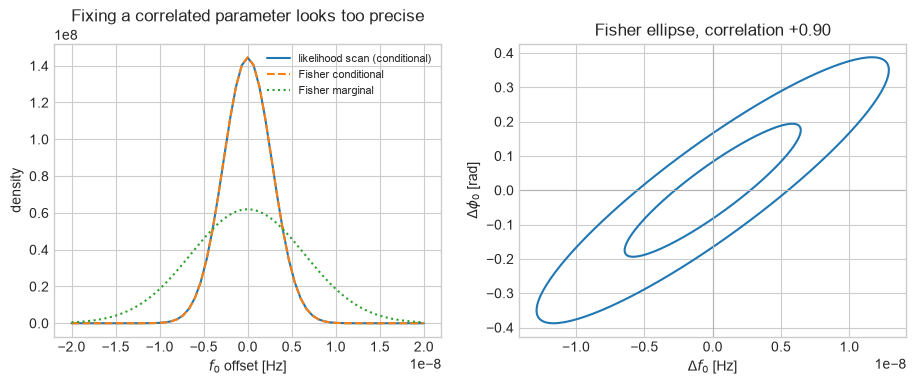

scan sigma(f0)        : 2.766e-09 Hz
conditional sigma(f0) : 2.759e-09 Hz
marginal sigma(f0)    : 6.446e-09 Hz


In [10]:
# Turn the earlier one-dimensional scan into a normalised posterior and
# compare its width with both Fisher predictions.
scan_posterior = np.exp(np.array(logL) - np.max(logL))
scan_posterior /= np.trapezoid(scan_posterior, offsets)
scan_mean = np.trapezoid(scan_posterior * offsets, offsets)
scan_sd = np.sqrt(np.trapezoid(scan_posterior * (offsets - scan_mean) ** 2, offsets))

angles = np.linspace(0, 2 * np.pi, 200)
circle = np.column_stack([np.cos(angles), np.sin(angles)])
block = fisher_covariance[np.ix_([0, 2], [0, 2])]
eigenvalues, eigenvectors = np.linalg.eigh(block)

fig, (scan_ax, ellipse_ax) = plt.subplots(1, 2, figsize=(11, 3.8))
scan_ax.plot(offsets, scan_posterior, label="likelihood scan (conditional)")
gaussian = np.exp(-0.5 * (offsets / conditional_sd[0]) ** 2)
scan_ax.plot(
    offsets,
    gaussian / np.trapezoid(gaussian, offsets),
    "--",
    label="Fisher conditional",
)
wide = np.exp(-0.5 * (offsets / marginal_sd[0]) ** 2)
scan_ax.plot(offsets, wide / np.trapezoid(wide, offsets), ":", label="Fisher marginal")
scan_ax.set(
    xlabel=r"$f_0$ offset [Hz]",
    ylabel="density",
    title="Fixing a correlated parameter looks too precise",
)
scan_ax.legend(fontsize=8)

for n_sigma in (1, 2):
    ellipse = n_sigma * circle @ (eigenvectors * np.sqrt(eigenvalues)).T
    ellipse_ax.plot(ellipse[:, 0], ellipse[:, 1], color="C0")
ellipse_ax.axvline(0, color="0.7", lw=0.8)
ellipse_ax.axhline(0, color="0.7", lw=0.8)
ellipse_ax.set(
    xlabel=r"$\Delta f_0$ [Hz]",
    ylabel=r"$\Delta\phi_0$ [rad]",
    title=f"Fisher ellipse, correlation {correlation[0, 2]:+.2f}",
)
plt.show()

print(f"scan sigma(f0)        : {scan_sd:.3e} Hz")
print(f"conditional sigma(f0) : {conditional_sd[0]:.3e} Hz")
print(f"marginal sigma(f0)    : {marginal_sd[0]:.3e} Hz")

### The same calculation with LISA Analysis Tools

The local `lisa_analysis_workshop` calls this abstraction an
`AnalysisContainer`. It bundles a `DataResidualArray` with a compatible
`SensitivityMatrix`, then exposes inner products, SNRs, and template
likelihoods. This does not replace understanding the formula—it reduces unit,
frequency-grid, and channel bookkeeping once the formula is understood.

In [11]:
warnings.filterwarnings("ignore", category=SyntaxWarning, module=r"lisatools\..*")
from lisatools.analysiscontainer import AnalysisContainer
from lisatools.datacontainer import DataResidualArray

latw_data = DataResidualArray(template, f_arr=frequency)
latw_sensitivity = SensitivityMatrix(
    frequency,
    [A1TDISens, E1TDISens],
    stochastic_params=(t_obs,),
)
latw_analysis = AnalysisContainer(latw_data, latw_sensitivity)

best_index = int(np.argmax(logL))
offset_index = 0
latw_best_template = DataResidualArray(trial_templates[best_index], f_arr=frequency)
latw_offset_template = DataResidualArray(trial_templates[offset_index], f_arr=frequency)

latw_optimal_snr, latw_detected_snr = latw_analysis.template_snr(latw_best_template)
latw_best_log_likelihood = latw_analysis.template_likelihood(latw_best_template)
latw_offset_log_likelihood = latw_analysis.template_likelihood(latw_offset_template)

print(f"AnalysisContainer optimal SNR: {latw_optimal_snr:.2f}")
print(f"AnalysisContainer detected SNR: {latw_detected_snr:.2f}")
print(
    "log-likelihood drop for an offset template:",
    f"{latw_offset_log_likelihood - latw_best_log_likelihood:.2f}",
)

AnalysisContainer optimal SNR: 12.06
AnalysisContainer detected SNR: 12.06
log-likelihood drop for an offset template: -25.07


## 5. The global-fit problem

The LATW challenge combines a massive-black-hole binary with groups of Galactic binaries. The GLASS demonstration writes the same idea schematically as
$$
d=h_{\rm UCB}+h_{\rm VGB}+h_{\rm MBHB}+n(\eta).
$$
No source is analysed against pristine data: each block sees a residual containing the current estimates of all other source and noise blocks. Source count may itself be unknown, motivating reversible-jump/trans-dimensional methods.

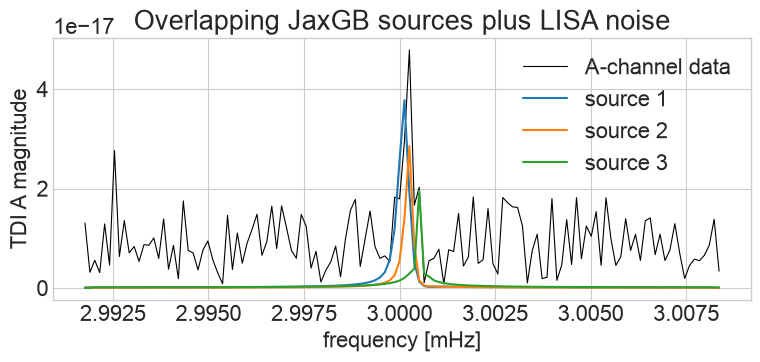

In [12]:
frequencies = np.array([3e-3, 3.00012e-3, 3.00025e-3])
true_scales = np.array([1.0, 0.72, 0.48])
catalogue = GBObject(
    f0=frequencies,
    fdot=np.array([1e-17, 0.5e-17, 1.5e-17]),
    A=np.full(3, 2e-22),
    ra=np.array([1.0, 1.4, 2.0]),
    dec=np.array([0.4, -0.2, 0.7]),
    psi=np.array([0.3, 0.8, 1.1]),
    iota=np.array([0.8, 1.2, 0.5]),
    phi0=np.array([0.2, 1.5, 2.4]),
    t_init=0.0,
)
all_parameters = catalogue.to_jaxgb_array(t0=0)
kmins = np.asarray(simulator.get_kmin(all_parameters[:, 0]))
kmin = int(kmins.min())
kmax = int(kmins.max() + simulator.n)
templates = []
for row in np.asarray(all_parameters):
    a, e, _ = simulator.sum_tdi(
        row[None, :], kmin, kmax, tdi_generation=2, tdi_combination="AET"
    )
    templates.append(np.stack([np.asarray(a), np.asarray(e)]))
templates = np.asarray(templates)
common_frequency = np.arange(kmin, kmax) / t_obs
common_psd = np.stack(
    [
        get_sensitivity(
            common_frequency, sens_fn=A1TDISens, stochastic_params=(t_obs,)
        ),
        get_sensitivity(
            common_frequency, sens_fn=E1TDISens, stochastic_params=(t_obs,)
        ),
    ]
)
noise = np.sqrt(common_psd / (4 * df)) * (
    rng.normal(size=common_psd.shape) + 1j * rng.normal(size=common_psd.shape)
)
data = np.sum(true_scales[:, None, None] * templates, axis=0) + noise


def global_inner(a, b):
    return 4 * df * np.real(np.sum(np.conj(a) * b / common_psd))


fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(
    1e3 * common_frequency, np.abs(data[0]), color="k", lw=0.8, label="A-channel data"
)
for i, h in enumerate(templates):
    ax.plot(
        1e3 * common_frequency, np.abs(true_scales[i] * h[0]), label=f"source {i+1}"
    )
ax.set(
    xlabel="frequency [mHz]",
    ylabel="TDI A magnitude",
    title="Overlapping JaxGB sources plus LISA noise",
)
ax.legend()
plt.show()

true       [1.   0.72 0.48]
one pass   [0.953 0.765 0.376]
joint      [0.992 0.766 0.379]
blocked    [0.992 0.766 0.379]


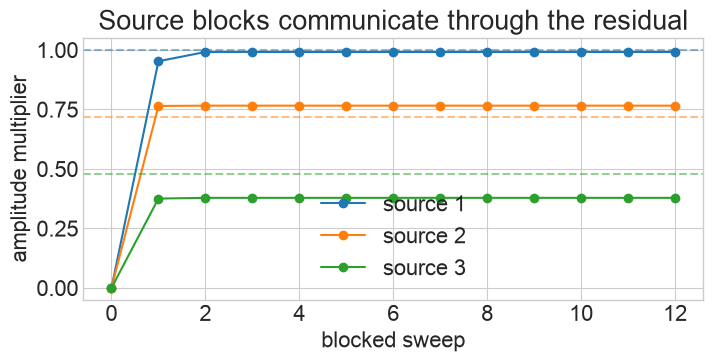

In [13]:
# One sequential pass, then a blocked conditional fit.
sequential = np.zeros(3)
residual = data.copy()
for i, h in enumerate(templates):
    sequential[i] = global_inner(h, residual) / global_inner(h, h)
    residual -= sequential[i] * h
blocked = np.zeros(3)
history = [blocked.copy()]
for sweep in range(12):
    for i, h in enumerate(templates):
        effective = (
            data - np.sum(blocked[:, None, None] * templates, axis=0) + blocked[i] * h
        )
        blocked[i] = global_inner(h, effective) / global_inner(h, h)
    history.append(blocked.copy())
history = np.asarray(history)

# The simultaneous weighted least-squares solution.
whitened_templates = (
    (np.sqrt(4 * df / common_psd)[None, :, :] * templates).reshape(3, -1).T
)
whitened_data = (np.sqrt(4 * df / common_psd) * data).ravel()
design = np.vstack([whitened_templates.real, whitened_templates.imag])
target = np.r_[whitened_data.real, whitened_data.imag]
joint = np.linalg.lstsq(design, target, rcond=None)[0]
print("true      ", np.round(true_scales, 3))
print("one pass  ", np.round(sequential, 3))
print("joint     ", np.round(joint, 3))
print("blocked   ", np.round(blocked, 3))
fig, ax = plt.subplots(figsize=(8, 3.4))
for i in range(3):
    ax.plot(history[:, i], "o-", label=f"source {i+1}")
    ax.axhline(true_scales[i], color=f"C{i}", ls="--", alpha=0.5)
ax.set(
    xlabel="blocked sweep",
    ylabel="amplitude multiplier",
    title="Source blocks communicate through the residual",
)
ax.legend()
plt.show()

## 6. A miniature unknown-source-count challenge

LATW Tutorial 6 uses RJMCMC so the number of Galactic binaries is inferred. Here we enumerate all eight subsets of three candidate templates and use BIC only as a fast classroom proxy—not as a replacement for evidence or RJMCMC.

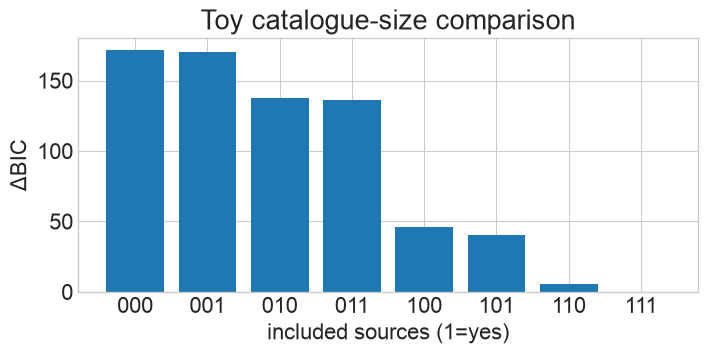

Preferred subset: 111 (the injected subset is 111)


In [14]:
model_scores = []
for included_bits in itertools.product([0, 1], repeat=3):
    included = np.flatnonzero(included_bits)
    model = np.zeros_like(data)
    n_parameters = len(included)
    if n_parameters:
        X = whitened_templates[:, included]
        D = np.vstack([X.real, X.imag])
        coefficients = np.linalg.lstsq(D, target, rcond=None)[0]
        model = np.sum(coefficients[:, None, None] * templates[included], axis=0)
    minus_two_logL = global_inner(data - model, data - model)
    bic = minus_two_logL + n_parameters * np.log(target.size)
    model_scores.append((included_bits, bic))
best = min(score for _, score in model_scores)
labels = ["".join(map(str, bits)) for bits, _ in model_scores]
delta = [score - best for _, score in model_scores]
fig, ax = plt.subplots(figsize=(8, 3.3))
ax.bar(labels, delta)
ax.set(
    xlabel="included sources (1=yes)",
    ylabel=r"$\Delta$BIC",
    title="Toy catalogue-size comparison",
)
plt.show()
print(
    "Preferred subset:", labels[int(np.argmin(delta))], "(the injected subset is 111)"
)

## Extension: animate the global residual

In [15]:
fig, ax = plt.subplots(figsize=(9, 3.3))
(line,) = ax.plot([], [], lw=0.8)
ax.set(
    xlim=(1e3 * common_frequency.min(), 1e3 * common_frequency.max()),
    ylim=(0, 1.1 * np.max(np.abs(data[0]))),
    xlabel="frequency [mHz]",
    ylabel="A residual magnitude",
)


def animate_residual(i):
    residual = data - np.sum(history[i, :, None, None] * templates, axis=0)
    line.set_data(1e3 * common_frequency, np.abs(residual[0]))
    ax.set_title(f"global residual after sweep {i}")
    return (line,)


animation = FuncAnimation(fig, animate_residual, frames=len(history), interval=220)
plt.close(fig)
display(HTML(animation.to_jshtml()))

## Optional LISA Data Challenge input and boundary

The LDC portal requires authentication, so the live notebook uses deterministic synthetic data. An authenticated student can later upload a selected file in Colab.

```python
from google.colab import files
uploaded = files.upload()
```

This notebook uses a real sensitivity model, orbit, and TDI response, but the global exercise fits three amplitude coefficients from a fixed candidate catalogue. A research global fit must infer nonlinear parameters, source count, multiple source classes and TDI channels, instrument/foreground noise, and demonstrate convergence and coverage.

Continue with:

- local `lisa_analysis_workshop/tutorials/Tutorial1.ipynb` for sensitivity/SNR/likelihood;
- Tutorial 6 for fixed-dimensional and RJ Galactic-binary inference;
- `LATW-challenge-problem.ipynb` for an MBHB plus two trans-dimensional GB groups;
- [GLASS global analysis](https://arxiv.org/abs/2301.03673);
- [LISA Data Challenge files](https://lisa-ldc.in2p3.fr/file).